In [1]:
import pandas as pd
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

In [2]:
tracks = pd.read_csv(
    r'C:\Users\Srikanth\srihome\project\data\fma_metadata\tracks.csv',
    index_col=0, header=[0, 1]
)

small = tracks[tracks['set', 'subset'] == 'small']

print("Number of tracks in FMA small:", len(small))
print("Genres:")
print(small['track', 'genre_top'].value_counts())

Number of tracks in FMA small: 8000
Genres:
(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


In [3]:
small[[('track', 'title'),
       ('track', 'genre_top'),
       ('set',   'subset')]].head()

track              set
                       title genre_top subset
track_id                                     
2                       Food   Hip-Hop  small
5                 This World   Hip-Hop  small
10                   Freeway       Pop  small
140       Queen Of The Wires      Folk  small
141                     Ohio      Folk  small

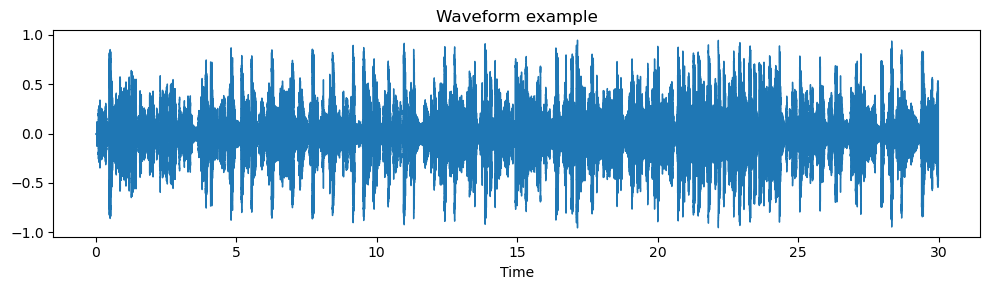

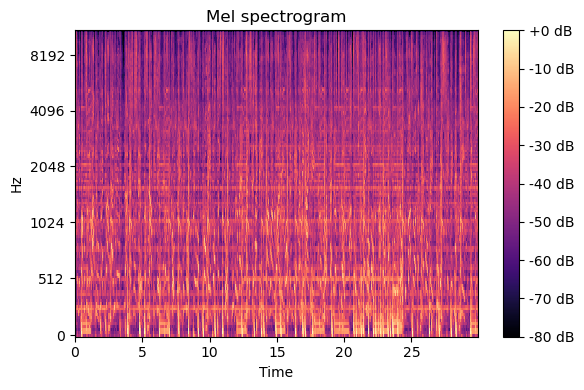

In [4]:
# look at one waveform and mel spectogram
audio_root = r"C:\Users\Srikanth\srihome\project\data\fma_small"

example_id = small.index[0]
tid = f"{int(example_id):06d}"
subfolder = tid[:3]
file_path = os.path.join(audio_root, subfolder, f"{tid}.mp3")

y, sr = librosa.load(file_path, sr=22050, mono=True)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform example")
plt.tight_layout()
plt.show()

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(6, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.f dB")
plt.title("Mel spectrogram")
plt.tight_layout()
plt.show()

In [5]:
# simple pitch shift augmentation
# we only augment the training data to give the model more variety to learn from

def augment_pitch(y, sr):
    n_steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

In [6]:
# extract mfcc + chroma + spectral contrast + zero crossing rate
# mfcc: timbre / tone color
# chroma: pitch class content, useful for harmonic genres like folk/pop
# spectral contrast: difference between peaks and valleys in spectrum, helps separate noisy vs tonal genres
# zero crossing rate: how noisy/percussive a signal is, useful for hip-hop vs folk

def extract_features(y, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).mean(axis=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr).mean(axis=1)
    zcr = librosa.feature.zero_crossing_rate(y=y).mean(axis=1)

    return np.concatenate([mfcc, chroma, contrast, zcr])


def extract_features_from_file(file_path, sr=22050, augment=False):
    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)
        if augment:
            y = augment_pitch(y, sr)
        return extract_features(y, sr)
    except Exception as e:
        return None

In [9]:
def build_split_features(small_df):
    X_train, y_train = [], []
    X_valid, y_valid = [], []
    X_test,  y_test  = [], []

    total = len(small_df)
    skipped = 0

    for i, (track_id, row) in enumerate(small_df.iterrows()):
        tid = f"{int(track_id):06d}"
        subfolder = tid[:3]
        file_path = os.path.join(audio_root, subfolder, f"{tid}.mp3")

        if not os.path.exists(file_path):
            skipped += 1
            continue

        split = row[('set', 'split')]
        genre = row[('track', 'genre_top')]

        feat = extract_features_from_file(file_path)

        if feat is None:
            skipped += 1
            continue

        if split == 'training':
            X_train.append(feat)
            y_train.append(genre)
        elif split == 'validation':
            X_valid.append(feat)
            y_valid.append(genre)
        elif split == 'test':
            X_test.append(feat)
            y_test.append(genre)

        if (i + 1) % 500 == 0:
            print(f"processed {i + 1} / {total} | skipped so far: {skipped}")

    print(f"\nDone. Total skipped (missing + corrupt): {skipped}")

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_valid, y_valid = np.array(X_valid), np.array(y_valid)
    X_test,  y_test  = np.array(X_test),  np.array(y_test)

    return X_train, y_train, X_valid, y_valid, X_test, y_test


X_train, y_train, X_valid, y_valid, X_test, y_test = build_split_features(small)

print("Train:", X_train.shape, "| genres:", np.unique(y_train))
print("Valid:", X_valid.shape, "| genres:", np.unique(y_valid))
print("Test: ", X_test.shape,  "| genres:", np.unique(y_test))

processed 500 / 8000 | skipped so far: 0
processed 1000 / 8000 | skipped so far: 0
processed 1500 / 8000 | skipped so far: 0
processed 2000 / 8000 | skipped so far: 0
processed 2500 / 8000 | skipped so far: 0
processed 3000 / 8000 | skipped so far: 0
processed 3500 / 8000 | skipped so far: 0
processed 4000 / 8000 | skipped so far: 0
processed 4500 / 8000 | skipped so far: 1
processed 5000 / 8000 | skipped so far: 2
processed 5500 / 8000 | skipped so far: 2
processed 6000 / 8000 | skipped so far: 2
processed 6500 / 8000 | skipped so far: 2
processed 7000 / 8000 | skipped so far: 3
processed 7500 / 8000 | skipped so far: 3
processed 8000 / 8000 | skipped so far: 3

Done. Total skipped (missing + corrupt): 3
Train: (6397, 33) | genres: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Valid: (800, 33) | genres: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Test:  (800, 33) | genres: ['Electronic' 'Expe

In [10]:
# class_weight balances genres that are harder to classify
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
clf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# quick manual check of a couple of max_depth values on validation set

for depth in [None, 20, 30]:
    clf_tmp = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    clf_tmp.fit(X_train, y_train)
    val_acc = accuracy_score(y_valid, clf_tmp.predict(X_valid))
    print(f"max_depth={depth} -> validation accuracy: {val_acc:.4f}")

max_depth=None -> validation accuracy: 0.4500
max_depth=20 -> validation accuracy: 0.4612
max_depth=30 -> validation accuracy: 0.4475


In [12]:
y_valid_pred = clf.predict(X_valid)
valid_acc = accuracy_score(y_valid, y_valid_pred)
print("Validation accuracy:", valid_acc)

y_test_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test accuracy (Top-1):", test_acc)

Validation accuracy: 0.45
Test accuracy (Top-1): 0.375


Classification report (per genre):
               precision    recall  f1-score   support

   Electronic      0.434     0.360     0.393       100
 Experimental      0.250     0.210     0.228       100
         Folk      0.195     0.230     0.211       100
      Hip-Hop      0.485     0.660     0.559       100
 Instrumental      0.365     0.350     0.357       100
International      0.402     0.470     0.433       100
          Pop      0.308     0.240     0.270       100
         Rock      0.545     0.480     0.511       100

     accuracy                          0.375       800
    macro avg      0.373     0.375     0.370       800
 weighted avg      0.373     0.375     0.370       800



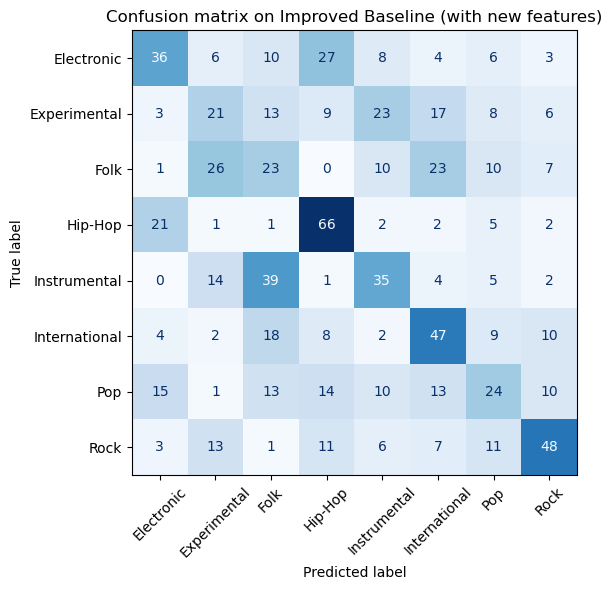

In [16]:
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

print("Classification report (per genre):")
print(classification_report(y_test, y_test_pred, digits=3))

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion matrix on Improved Baseline (with new features)")
plt.tight_layout()
plt.show()

In [22]:
print(  f"Baseline test accuracy was 0.3425, new test accuracy is {test_acc:.4f}")

Baseline test accuracy was 0.3425, new test accuracy is 0.3750


Summary of improvements made compared to baseline:
1. Added chroma, spectral contrast and zero crossing rate features; baseline only used MFCC.
2. Added pitch shift augmentation on training data.
3. Used class_weight='balanced' to help genres with lower F1 scores (Pop, Folk, Experimental).
4. Did a small hyperparameter check on max_depth using the validation set.
Baseline test accuracy was 0.3425, new test accuracy is 0.3750